# 03 — Full RAG Evaluation, Plots, and Failure Inspection

This notebook evaluates the full RAG system with the production retrieval profile.

It performs:
1. retrieval ablation refresh
2. generation evaluation with `hybrid_rerank`
3. automatic plot generation
4. failure inspection and error breakdown


In [1]:

from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\aminl\Desktop\PORTFOLIO Projects\final list - V2\aegis-rag-v4


In [2]:

from scripts.config import (
    EVAL_DIR,
    PLOTS_DIR,
    LLM_MODEL,
    JUDGE_MODEL,
    RESULTS_RETRIEVAL_FILE,
    RESULTS_GENERATION_FILE,
    RESULTS_SUMMARY_FILE,
    RESULTS_FAILURES_FILE,
    RESULTS_ABLATION_FILE,
    EXPERIMENT_MANIFEST_FILE,
    RETRIEVAL_PROFILES,
    save_experiment_manifest,
)
from scripts.retriever import HybridRetriever
import scripts.eval as eval_mod

retrieval_gold = eval_mod.load_json(EVAL_DIR / "retrieval_gold.json")
qa_gold = eval_mod.load_json(EVAL_DIR / "qa_gold.json")

print("retrieval_gold:", len(retrieval_gold), "| qa_gold:", len(qa_gold))


retrieval_gold: 20 | qa_gold: 20


## Build retriever and save experiment manifest

In [3]:

TARGET_PROFILE = "hybrid_rerank"

retriever = HybridRetriever(profile_name=TARGET_PROFILE)
save_experiment_manifest(EXPERIMENT_MANIFEST_FILE)

print("Retriever ready for profile:", TARGET_PROFILE)
print("Manifest saved to:", EXPERIMENT_MANIFEST_FILE)


Retriever ready for profile: hybrid_rerank
Manifest saved to: C:\Users\aminl\Desktop\PORTFOLIO Projects\final list - V2\aegis-rag-v4\data\eval\experiment_manifest.json


## Refresh retrieval ablation and plots

In [4]:

ablation_results = [
    eval_mod.evaluate_retrieval_profile(retrieval_gold, profile_name)
    for profile_name in RETRIEVAL_PROFILES.keys()
]
eval_mod.save_json(ablation_results, RESULTS_ABLATION_FILE)
eval_mod.plot_retrieval_profiles(ablation_results, PLOTS_DIR)

ablation_df = pd.DataFrame([
    {"profile_name": item["profile_name"], **item["aggregate"]}
    for item in ablation_results
]).sort_values(["ndcg@5", "recall@5"], ascending=False)

ablation_df


,profile_name,recall@5,recall@10,ndcg@5,mrr,qps,avg_latency_sec
3,hybrid_rerank,0.850000,0.85,0.800158,0.825000,10.520724,0.095050
1,dense_only,0.766667,0.90,0.728674,0.792500,17.402784,0.057462
0,bm25_only,0.766667,0.85,0.721374,0.770833,4436.557232,0.000225
2,hybrid,0.850000,0.85,0.689476,0.695833,17.733163,0.056392


## Evaluate generation with `hybrid_rerank`

In [5]:
best_retrieval = next(x for x in ablation_results if x["profile_name"] == TARGET_PROFILE)

generation_results = eval_mod.evaluate_generation(
    qa_gold=qa_gold,
    retriever=retriever,
    model_name=LLM_MODEL,
    judge_model=JUDGE_MODEL,
    profile_name=TARGET_PROFILE,
    request_timeout=300,
    ragas_retries=2,
    skip_ragas=False,
)

failures = eval_mod.build_failure_report(qa_gold, retrieval_gold, generation_results)
summary_rows = eval_mod.build_summary_rows(best_retrieval, generation_results)

eval_mod.save_json(best_retrieval, RESULTS_RETRIEVAL_FILE)
eval_mod.save_json(generation_results, RESULTS_GENERATION_FILE)
eval_mod.save_json(failures, RESULTS_FAILURES_FILE)
eval_mod.save_summary_csv(summary_rows, RESULTS_SUMMARY_FILE)

print("Saved retrieval results →", RESULTS_RETRIEVAL_FILE)
print("Saved generation results →", RESULTS_GENERATION_FILE)
print("Saved failures →", RESULTS_FAILURES_FILE)
print("Saved summary →", RESULTS_SUMMARY_FILE)

pd.DataFrame(summary_rows)

C:\Users\aminl\anaconda3\envs\pytorch-gpu\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Saved retrieval results → C:\Users\aminl\Desktop\PORTFOLIO Projects\final list - V2\aegis-rag-v4\data\eval\results_retrieval.json
Saved generation results → C:\Users\aminl\Desktop\PORTFOLIO Projects\final list - V2\aegis-rag-v4\data\eval\results_generation.json
Saved failures → C:\Users\aminl\Desktop\PORTFOLIO Projects\final list - V2\aegis-rag-v4\data\eval\results_failures.json
Saved summary → C:\Users\aminl\Desktop\PORTFOLIO Projects\final list - V2\aegis-rag-v4\data\eval\results_summary.csv


,model_name,judge_model,profile_name,retrieval_recall@5,retrieval_recall@10,retrieval_ndcg@5,retrieval_mrr,retrieval_qps,retrieval_avg_latency_sec,generation_faithfulness,...,generation_exact_match,generation_semantic_match,generation_avg_latency_sec,generation_avg_tokens_per_answer_est,generation_avg_top_rerank_score,generation_avg_top_fused_score,generation_qps,num_examples,num_ragas_missing,ragas_error
0,llama3.1:8b,llama3.1:8b,hybrid_rerank,0.85,0.85,0.800158,0.825,10.520724,0.09505,0.666667,...,0.25,0.751134,0.729988,18.2,2.479069,0.028424,1.369885,20,0,None


## Generated plots

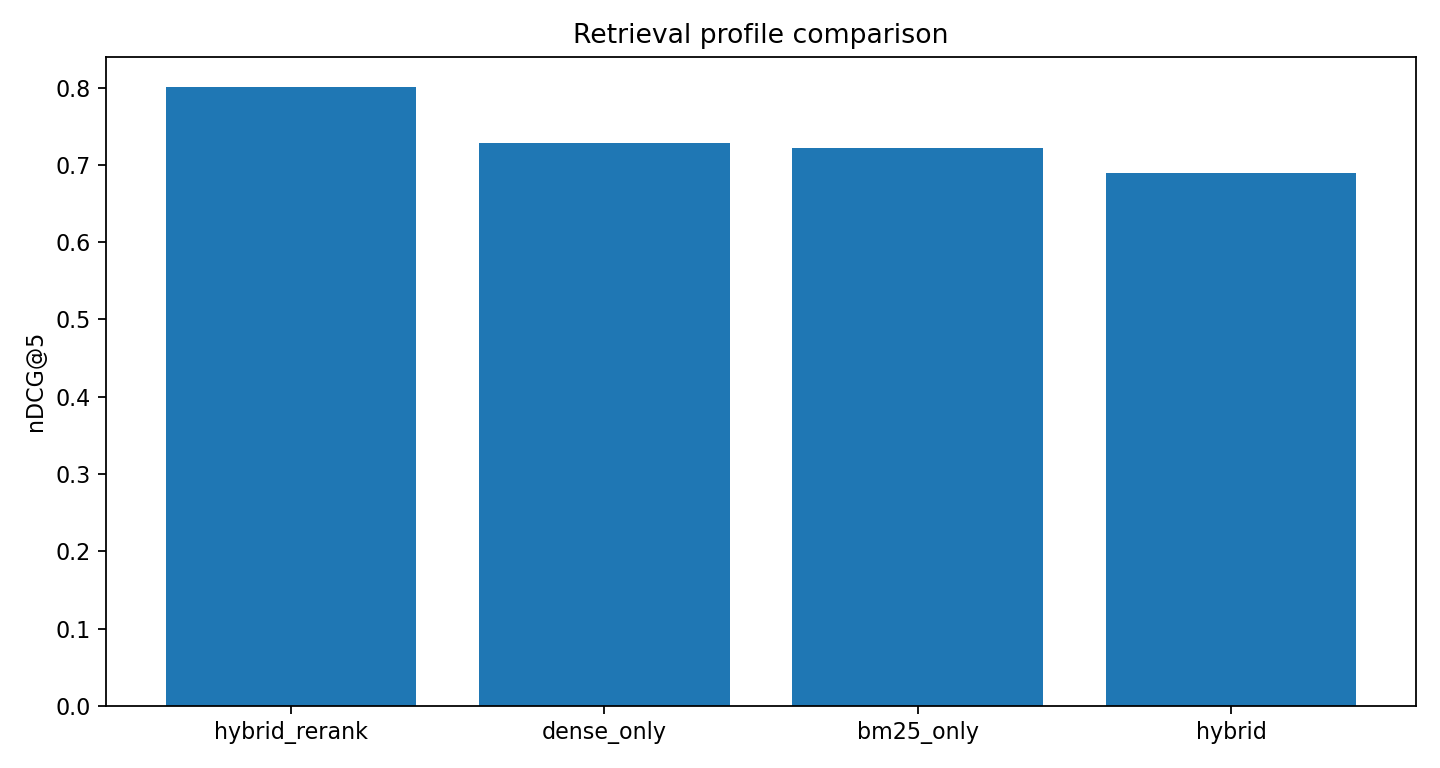

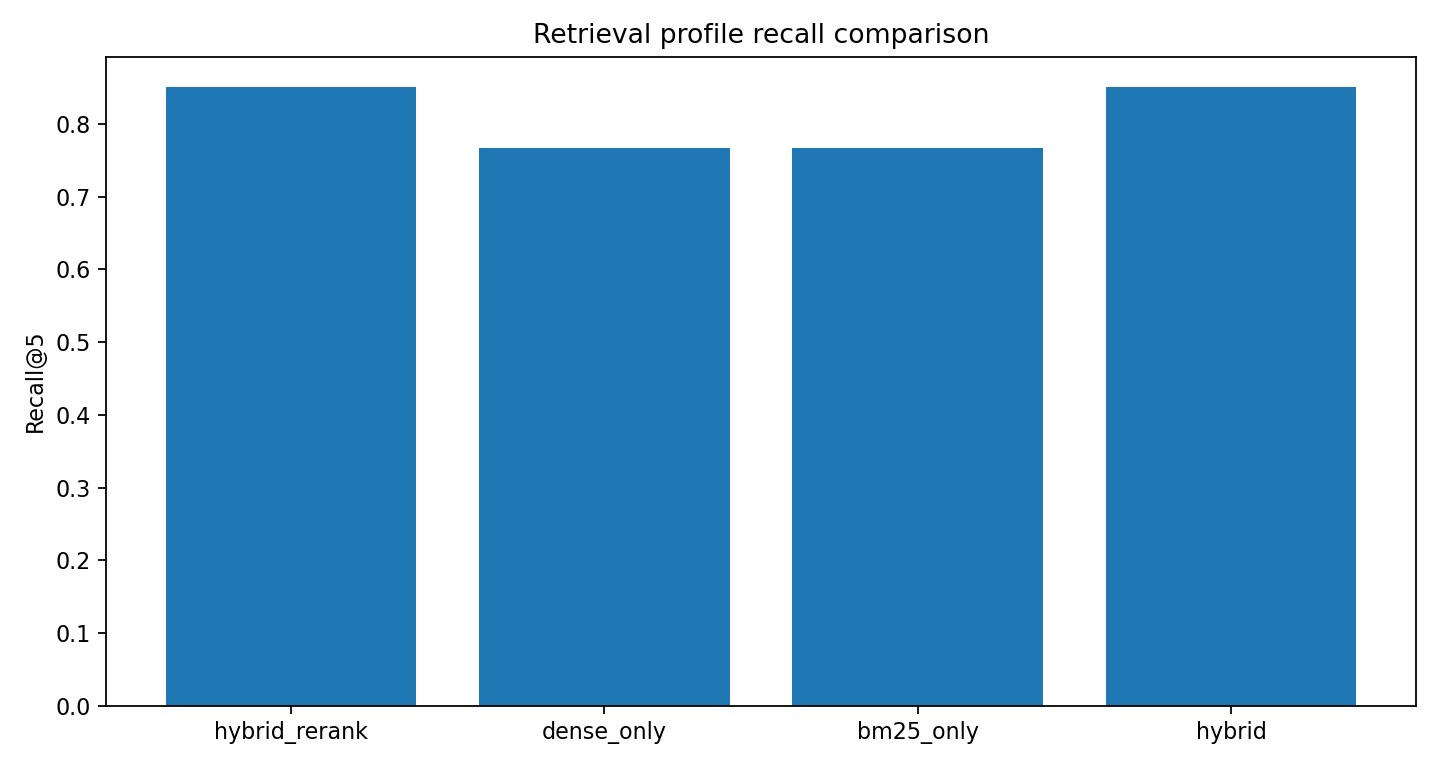

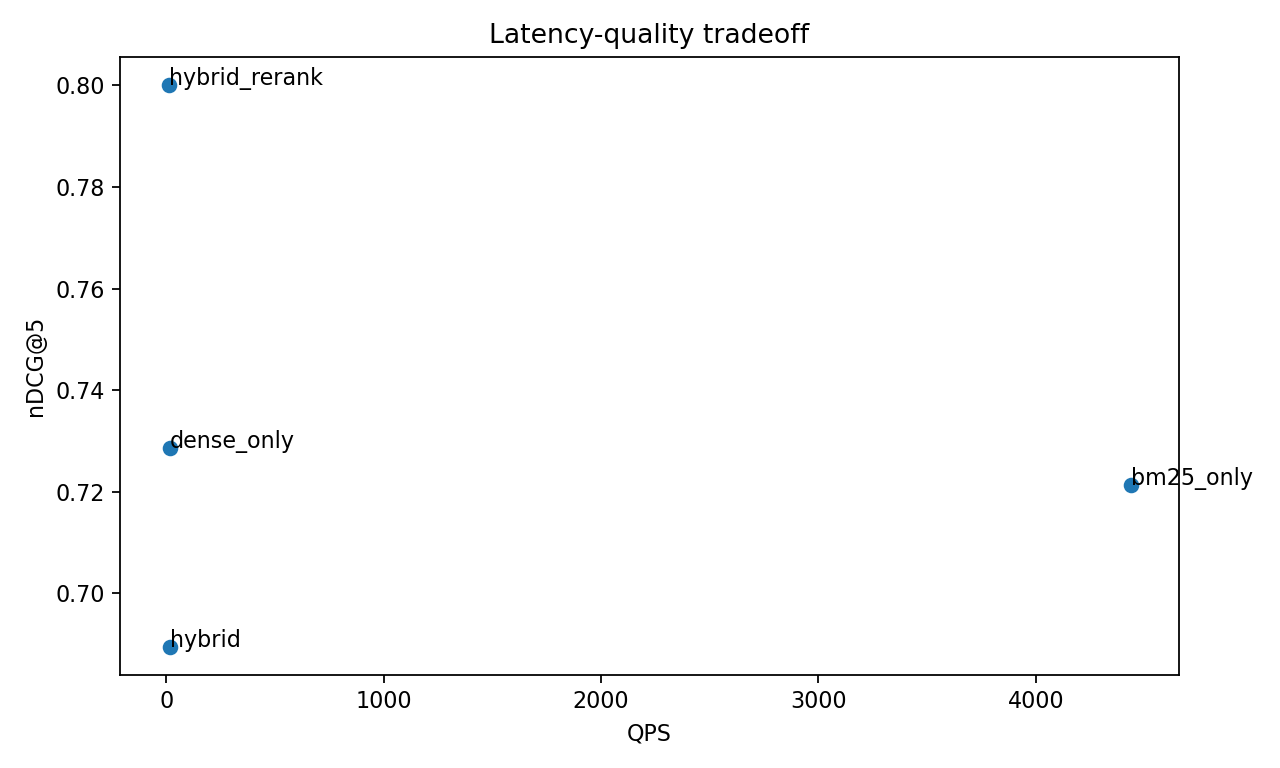

In [6]:
display(Image(filename=str(PLOTS_DIR / "retrieval_profile_ndcg.png")))
display(Image(filename=str(PLOTS_DIR / "retrieval_profile_recall.png")))
display(Image(filename=str(PLOTS_DIR / "latency_quality_tradeoff.png")))

## Failure breakdown

In [7]:
failures_df = pd.DataFrame(failures)
failures_df["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")

,error_type,count
0,correct,14
1,generation_hallucination,3
2,correct_no_answer,2
3,ranking_or_answer_miss,1


## Inspect non-correct cases

In [8]:
non_correct_df = failures_df[failures_df["error_type"] != "correct"].copy()
non_correct_df[[
    "id", "question", "error_type", "ground_truth", "answer", "faithfulness", "semantic_match"
]].head(20)

,id,question,error_type,ground_truth,answer,faithfulness,semantic_match
1,1,Can I check in at noon for free?,generation_hallucination,No. Guests may request early access beginning ...,I cannot find sufficient evidence in the sourc...,0.0,0.113373
5,5,Can I stay after 2 PM without paying?,generation_hallucination,"No, departures later than the approved window ...",I cannot find sufficient evidence in the sourc...,0.0,0.186367
6,6,Are pets allowed and what is the fee?,correct_no_answer,I cannot find sufficient evidence in the sourc...,I cannot find sufficient evidence in the sourc...,0.0,1.000000
10,10,What internet network should I use?,generation_hallucination,Join SweetSpot_Guest and complete the browser-...,I cannot find sufficient evidence in the sourc...,0.0,-0.019481
12,12,What happens if I don’t have a receipt?,ranking_or_answer_miss,The claimant should provide a written explanat...,I cannot find sufficient evidence in the sourc...,0.5,0.313837
19,19,Does the hotel have a swimming pool?,correct_no_answer,I cannot find sufficient evidence in the sourc...,I cannot find sufficient evidence in the sourc...,0.5,1.000000


## Deep dive by error type

In [9]:
error_type = "generation_hallucination"
subset = failures_df[failures_df["error_type"] == error_type][[
    "id", "question", "ground_truth", "answer", "retrieved_ids", "relevant_ids"
]]
print("Rows for", error_type, ":", len(subset))
subset.head(10)

Rows for generation_hallucination : 3


,id,question,ground_truth,answer,retrieved_ids,relevant_ids
1,1,Can I check in at noon for free?,No. Guests may request early access beginning ...,I cannot find sufficient evidence in the sourc...,[08_Corporate_Stay_FAQ_for_Sponsored_Guests_p1...,"[01_Guest_Stay_and_Incidentals_Handbook_p1_c1,..."
5,5,Can I stay after 2 PM without paying?,"No, departures later than the approved window ...",I cannot find sufficient evidence in the sourc...,"[01_Guest_Stay_and_Incidentals_Handbook_p1_c1,...",[01_Guest_Stay_and_Incidentals_Handbook_p1_c1]
10,10,What internet network should I use?,Join SweetSpot_Guest and complete the browser-...,I cannot find sufficient evidence in the sourc...,"[11_Wi-Fi_and_Network_Access_Policy_p2_c1, 11_...",[08_Corporate_Stay_FAQ_for_Sponsored_Guests_p2...


## Review aggregate metrics

In [10]:
generation_results['aggregate']

{'faithfulness': 0.6666666666666667,
 'answer_relevancy': 0.6651140204338567,
 'context_precision': 0.8291666666302084,
 'exact_match': 0.25,
 'semantic_match': 0.7511342860758304,
 'avg_latency_sec': 0.7299880200000188,
 'avg_tokens_per_answer_est': 18.2,
 'avg_top_rerank_score': 2.4790690895169973,
 'avg_top_fused_score': 0.028423504384740693,
 'qps': 1.3698854948331538,
 'num_examples': 20,
 'num_ragas_missing': 0}

## Suggested workflow

- run `01_data_ingestion_and_chunking.ipynb` after updating PDFs
- run `02_hybrid_retrieval_baseline.ipynb` to compare retrieval profiles
- run this notebook with `TARGET_PROFILE = "hybrid_rerank"` for the full production evaluation
- inspect `results_failures.json` whenever quality drops
